In [1]:
# CELL 1
import os
import numpy as np
import random
import tensorflow as tf
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from tensorflow import keras
from tensorflow.keras import layers
import re

# reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Reproducibility enabled")

# dataset root
CLEAN_ROOT = Path("cleaned_data_lstm")


Reproducibility enabled


In [2]:
# CELL 2 
# =========================================
# WINDOWING
# =========================================

FS = 50
WIN_LEN = 200
STRIDE = 100

print("Window length:", WIN_LEN)
print("Stride:", STRIDE)

def make_windows(X):

    T, F = X.shape

    # If trial is shorter than window, pad with zeros
    if T < WIN_LEN:
        w = np.zeros((WIN_LEN, F))
        w[:T] = X
        return w[None,:,:]

    windows = []

    for i in range(0, T - WIN_LEN + 1, STRIDE):
        windows.append(X[i:i+WIN_LEN])

    return np.array(windows)

Window length: 200
Stride: 100


In [3]:
# CELL 3 
POSTURES = sorted([p.name for p in CLEAN_ROOT.iterdir() if p.is_dir()])
LABEL_TO_ID = {p:i for i,p in enumerate(POSTURES)}

print("Postures:", POSTURES)
print("Number of classes:", len(POSTURES))

SUBJECT_RE = re.compile(r"Sub_(\d+)_Trial_(\d+)\.csv")

rows = []

for posture in POSTURES:

    for f in (CLEAN_ROOT/posture).glob("*.csv"):

        m = SUBJECT_RE.search(f.name)

        if m:

            rows.append({
                "path": f,
                "posture": posture,
                "label": LABEL_TO_ID[posture],
                "subject": int(m.group(1)),
                "trial": int(m.group(2))
            })

df_items = pd.DataFrame(rows)

print("Total cleaned files:", len(df_items))
print("Subjects:", df_items["subject"].nunique())
print("Trials:", df_items["trial"].nunique())

Postures: ['1', '2', '3', '4', '5', '6']
Number of classes: 6
Total cleaned files: 828
Subjects: 46
Trials: 18


In [ ]:
# CELL 4 
# =========================================
# CREATE WINDOW DATASET (ACC + EULER ONLY)
# =========================================

X_all = []
y_all = []
subj_all = []
trial_all = []

window_counter = 0

for _, row in df_items.iterrows():

    X_full = pd.read_csv(row["path"]).values

    # ---------------------------------
    # ACC + EULER (6 features per sensor)
    # ---------------------------------
    acc_euler_slices = [
        np.r_[0:3, 12:15],     # L5
        np.r_[15:18, 27:30],   # T4
        np.r_[30:33, 42:45],   # C7
        np.r_[45:48, 57:60]    # T12
    ]

    X = np.concatenate([X_full[:, s] for s in acc_euler_slices], axis=1)

    windows = make_windows(X)

    for w in windows:
        X_all.append(w)
        y_all.append(row["label"])
        subj_all.append(row["subject"])
        trial_all.append(row["trial"])

    window_counter += len(windows)


X_all = np.array(X_all)
y_all = np.array(y_all)
subj_all = np.array(subj_all)
trial_all = np.array(trial_all)

print("\n===== DATASET SUMMARY =====")
print("Total windows:", window_counter)
print("X shape:", X_all.shape)  # should be (N, 200, 24)
print("Features per timestep:", X_all.shape[2])


===== DATASET SUMMARY =====
Total windows: 11549
X shape: (11549, 200, 24)
Features per timestep: 24


In [ ]:
# CELL 5
# =========================================
# NORMALIZATION (ACC + EULER → 6 per sensor)
# =========================================

SENSOR_SLICES = [
    slice(0,6),
    slice(6,12),
    slice(12,18),
    slice(18,24)
]

def compute_sensor_norm(X):

    means = []
    stds  = []

    for s in SENSOR_SLICES:

        sensor_data = X[:,:,s]
        flat = sensor_data.reshape(-1, sensor_data.shape[-1])

        mean = flat.mean(axis=0, keepdims=True)
        std  = flat.std(axis=0, keepdims=True) + 1e-8

        means.append(mean)
        stds.append(std)

    return means, stds


def apply_sensor_norm(X, means, stds):

    Xn = X.copy()

    for s, mean, std in zip(SENSOR_SLICES, means, stds):
        Xn[:,:,s] = (X[:,:,s] - mean) / std

    return Xn

In [ ]:
# CELL 6
class SensorDropout(layers.Layer):

    def __init__(self, drop_prob=0.2):
        super().__init__()
        self.drop_prob = drop_prob

    def call(self, x, training=None):

        if not training:
            return x

        batch = tf.shape(x)[0]
        n_sensors = 4
        feat_per_sensor = tf.shape(x)[-1] // n_sensors

        mask = tf.cast(
            tf.random.uniform((batch, n_sensors, 1)) > self.drop_prob,
            x.dtype
        )

        mask = tf.repeat(mask, repeats=feat_per_sensor, axis=2)
        mask = tf.reshape(mask, (batch, 1, n_sensors * feat_per_sensor))

        return x * mask

In [ ]:
# CELL 7
# =========================================
# MODEL WITH ATTENTION EXTRACTION
# =========================================

def build_model(input_shape):

    inp = keras.Input(shape=input_shape)

    print("Model input:", input_shape)

    x = SensorDropout(0.25)(inp)

    # ---------------------------------
    # Split sensors (ACC + EULER → 6 each)
    # ---------------------------------

    L5  = layers.Lambda(lambda x: x[:,:,0:6])(x)
    T4  = layers.Lambda(lambda x: x[:,:,6:12])(x)
    C7  = layers.Lambda(lambda x: x[:,:,12:18])(x)
    T12 = layers.Lambda(lambda x: x[:,:,18:24])(x)

    print("Sensor feature size:", 6)

    # ---------------------------------
    # Sensor CNN block WITH NAMED ATTENTION
    # ---------------------------------

    def sensor_block(x, name_prefix):

        x = layers.Conv1D(32, 5, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Conv1D(32, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)

        attention = layers.Dense(32, activation="tanh", name=f"{name_prefix}_feat_dense")(x)
        attention = layers.Softmax(axis=-1, name=f"{name_prefix}_feat_softmax")(attention)

        x = layers.Multiply(name=f"{name_prefix}_feat_mul")([x, attention])

        return x, attention


    L5,  L5_feat_att  = sensor_block(L5,  "L5")
    T4,  T4_feat_att  = sensor_block(T4,  "T4")
    C7,  C7_feat_att  = sensor_block(C7,  "C7")
    T12, T12_feat_att = sensor_block(T12, "T12")

    # ---------------------------------
    # Stack sensors
    # ---------------------------------

    sensors = layers.Lambda(lambda x: tf.stack(x, axis=2))([L5, T4, C7, T12])

    # ---------------------------------
    # Sensor attention (NAMED)
    # ---------------------------------

    sensor_attention = layers.Dense(1, activation="tanh", name="sensor_dense")(sensors)
    sensor_attention = layers.Softmax(axis=2, name="sensor_softmax")(sensor_attention)

    sensors = layers.Multiply()([sensors, sensor_attention])

    fused = layers.Lambda(lambda x: tf.reduce_sum(x, axis=2))(sensors)

    # ---------------------------------
    # Temporal pooling
    # ---------------------------------

    x = layers.GlobalAveragePooling1D()(fused)

    # ---------------------------------
    # Classifier
    # ---------------------------------

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(len(POSTURES), activation="softmax")(x)

    model = keras.Model(inp, out)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"]
    )

    # 🔥 IMPORTANT: attach attention tensors
    model.feature_attentions = [L5_feat_att, T4_feat_att, C7_feat_att, T12_feat_att]
    model.sensor_attention = sensor_attention

    model.summary()

    return model

In [8]:
# CELL 8

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


TEST SUBJECT: 1

Model input: (200, 24)
Sensor feature size: 6
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout (SensorDrop  (None, 200, 24)              0         ['input_1[0][0]']             
 out)                                                                                             
                                                                                                  
 lambda (Lambda)             (None, 200, 6)               0         ['sensor_dropout[0][0]']      
                                                                                                  
 lambda_1 (Lambda)           (

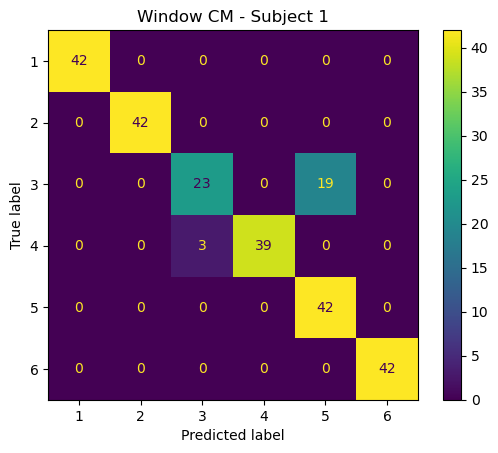


TRIAL ACC: 0.9444444444444444
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         3
           5       0.75      1.00      0.86         3
           6       1.00      1.00      1.00         3

    accuracy                           0.94        18
   macro avg       0.96      0.94      0.94        18
weighted avg       0.96      0.94      0.94        18



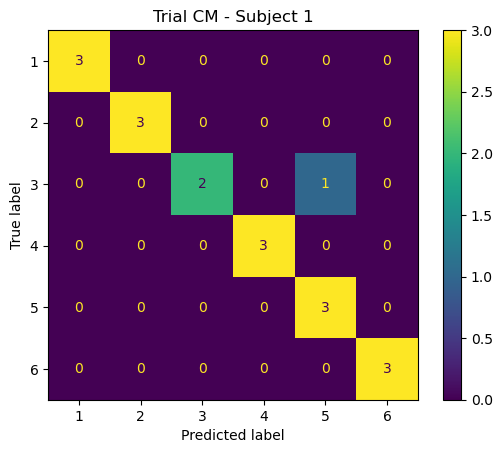


TEST SUBJECT: 2
Model input: (200, 24)
Sensor feature size: 6
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_1 (SensorDr  (None, 200, 24)              0         ['input_2[0][0]']             
 opout)                                                                                           
                                                                                                  
 lambda_6 (Lambda)           (None, 200, 6)               0         ['sensor_dropout_1[0][0]']    
                                                                                                  
 lambda_7 (Lambda)           

c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


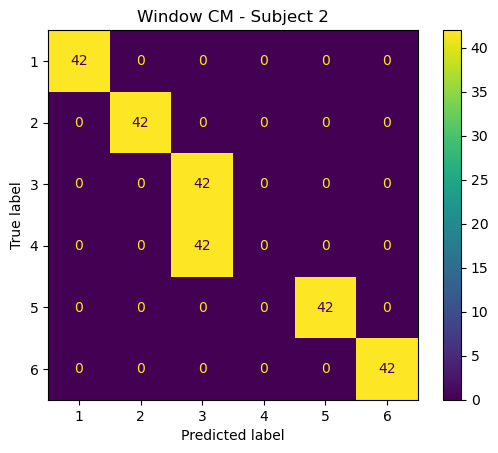


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.50      1.00      0.67         3
           4       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.75      0.83      0.78        18
weighted avg       0.75      0.83      0.78        18



c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


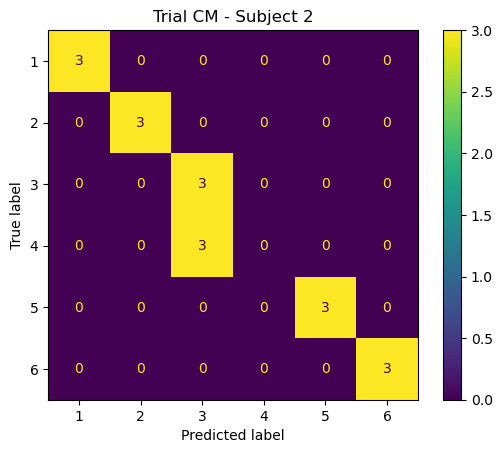


TEST SUBJECT: 3
Model input: (200, 24)
Sensor feature size: 6
Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_2 (SensorDr  (None, 200, 24)              0         ['input_3[0][0]']             
 opout)                                                                                           
                                                                                                  
 lambda_12 (Lambda)          (None, 200, 6)               0         ['sensor_dropout_2[0][0]']    
                                                                                                  
 lambda_13 (Lambda)          

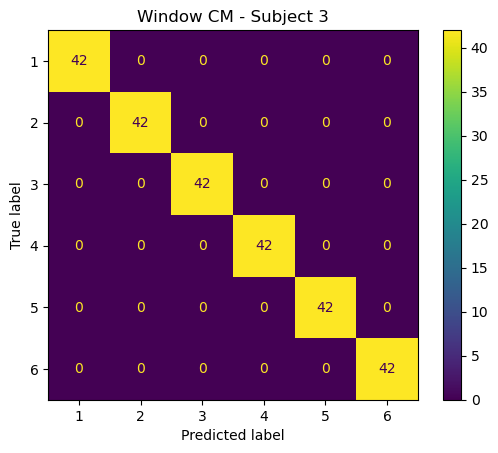


TRIAL ACC: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



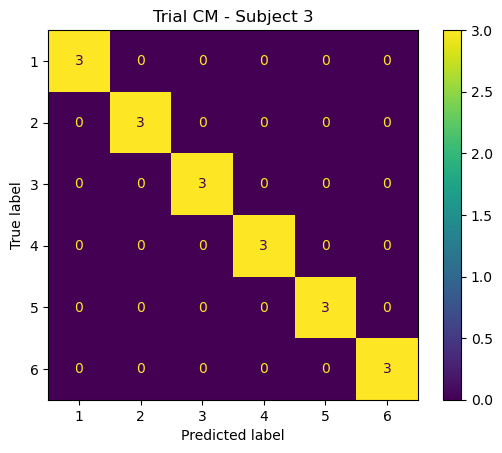


TEST SUBJECT: 4
Model input: (200, 24)
Sensor feature size: 6
Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_3 (SensorDr  (None, 200, 24)              0         ['input_4[0][0]']             
 opout)                                                                                           
                                                                                                  
 lambda_18 (Lambda)          (None, 200, 6)               0         ['sensor_dropout_3[0][0]']    
                                                                                                  
 lambda_19 (Lambda)          

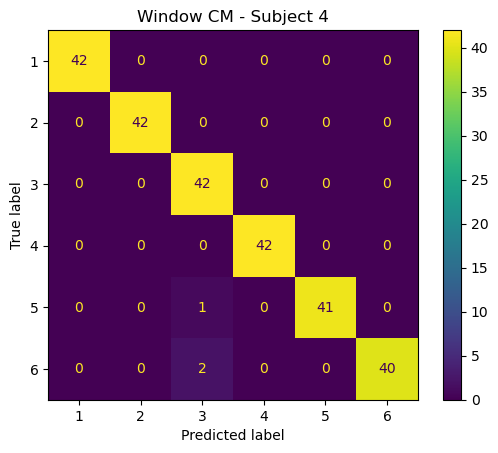


TRIAL ACC: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



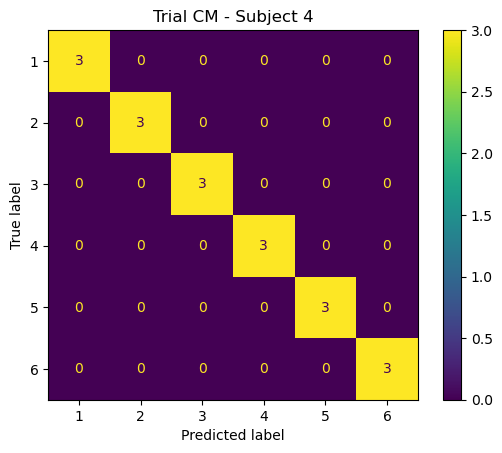


TEST SUBJECT: 5
Model input: (200, 24)
Sensor feature size: 6
Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_4 (SensorDr  (None, 200, 24)              0         ['input_5[0][0]']             
 opout)                                                                                           
                                                                                                  
 lambda_24 (Lambda)          (None, 200, 6)               0         ['sensor_dropout_4[0][0]']    
                                                                                                  
 lambda_25 (Lambda)          

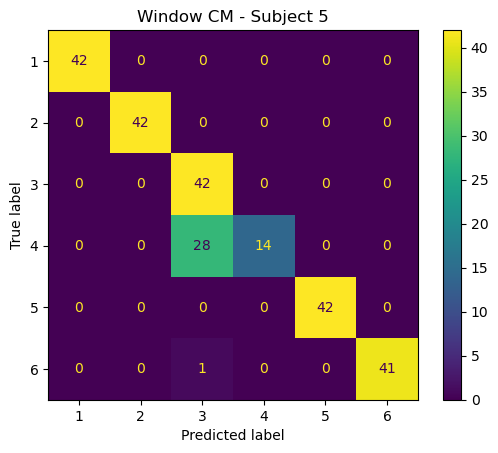


TRIAL ACC: 0.8888888888888888
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.60      1.00      0.75         3
           4       1.00      0.33      0.50         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.89        18
   macro avg       0.93      0.89      0.88        18
weighted avg       0.93      0.89      0.88        18



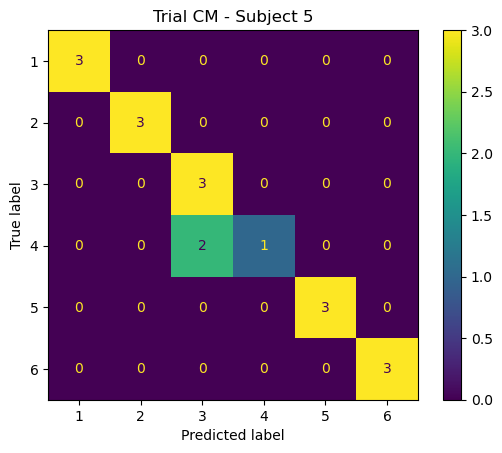


TEST SUBJECT: 6
Model input: (200, 24)
Sensor feature size: 6
Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_6 (InputLayer)        [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_5 (SensorDr  (None, 200, 24)              0         ['input_6[0][0]']             
 opout)                                                                                           
                                                                                                  
 lambda_30 (Lambda)          (None, 200, 6)               0         ['sensor_dropout_5[0][0]']    
                                                                                                  
 lambda_31 (Lambda)          

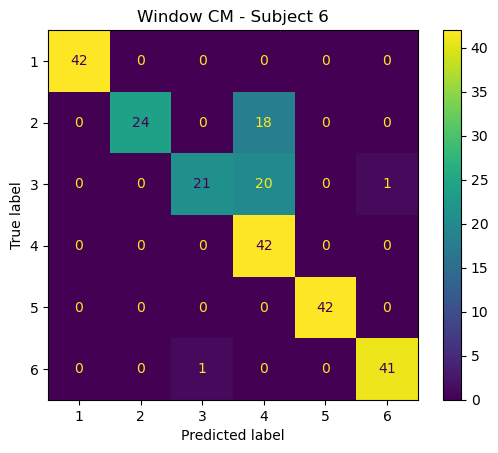


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      0.33      0.50         3
           3       1.00      0.67      0.80         3
           4       0.50      1.00      0.67         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.92      0.83      0.83        18
weighted avg       0.92      0.83      0.83        18



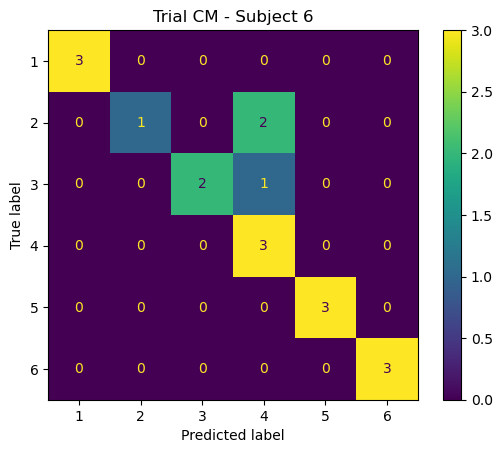


TEST SUBJECT: 7
Model input: (200, 24)
Sensor feature size: 6
Model: "model_6"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_7 (InputLayer)        [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_6 (SensorDr  (None, 200, 24)              0         ['input_7[0][0]']             
 opout)                                                                                           
                                                                                                  
 lambda_36 (Lambda)          (None, 200, 6)               0         ['sensor_dropout_6[0][0]']    
                                                                                                  
 lambda_37 (Lambda)          

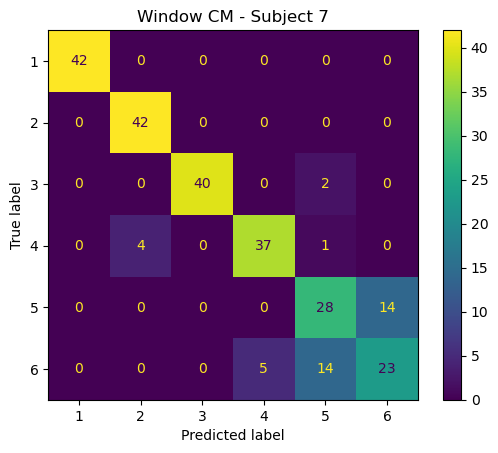


TRIAL ACC: 0.8888888888888888
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       0.67      0.67      0.67         3
           6       0.67      0.67      0.67         3

    accuracy                           0.89        18
   macro avg       0.89      0.89      0.89        18
weighted avg       0.89      0.89      0.89        18



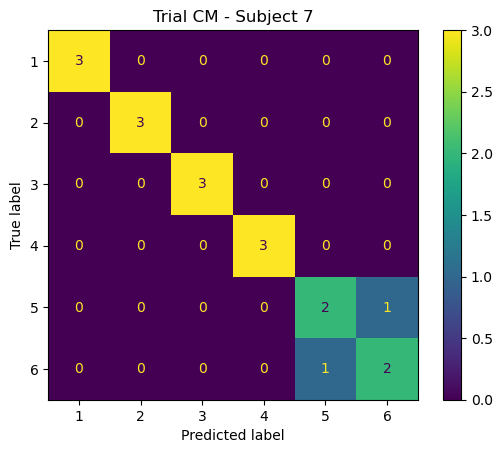


TEST SUBJECT: 8
Model input: (200, 24)
Sensor feature size: 6
Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_8 (InputLayer)        [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_7 (SensorDr  (None, 200, 24)              0         ['input_8[0][0]']             
 opout)                                                                                           
                                                                                                  
 lambda_42 (Lambda)          (None, 200, 6)               0         ['sensor_dropout_7[0][0]']    
                                                                                                  
 lambda_43 (Lambda)          

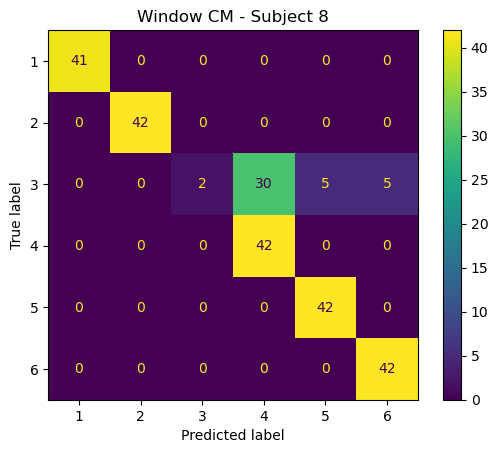


TRIAL ACC: 0.8888888888888888
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.33      0.50         3
           4       0.60      1.00      0.75         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.89        18
   macro avg       0.93      0.89      0.88        18
weighted avg       0.93      0.89      0.88        18



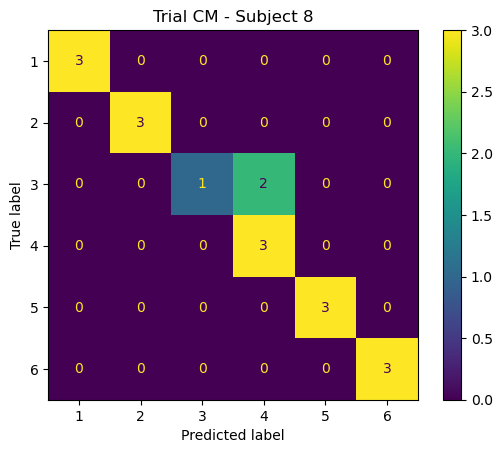


TEST SUBJECT: 9
Model input: (200, 24)
Sensor feature size: 6
Model: "model_8"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_9 (InputLayer)        [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_8 (SensorDr  (None, 200, 24)              0         ['input_9[0][0]']             
 opout)                                                                                           
                                                                                                  
 lambda_48 (Lambda)          (None, 200, 6)               0         ['sensor_dropout_8[0][0]']    
                                                                                                  
 lambda_49 (Lambda)          

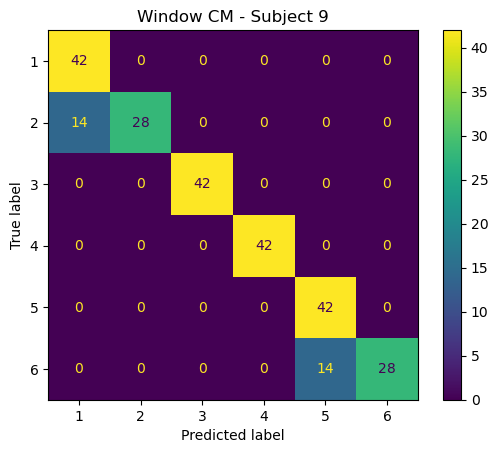


TRIAL ACC: 0.8888888888888888
              precision    recall  f1-score   support

           1       0.75      1.00      0.86         3
           2       1.00      0.67      0.80         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       0.75      1.00      0.86         3
           6       1.00      0.67      0.80         3

    accuracy                           0.89        18
   macro avg       0.92      0.89      0.89        18
weighted avg       0.92      0.89      0.89        18



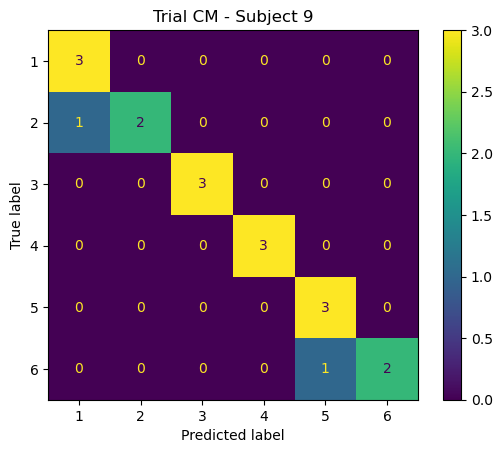


TEST SUBJECT: 10
Model input: (200, 24)
Sensor feature size: 6
Model: "model_9"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_10 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_9 (SensorDr  (None, 200, 24)              0         ['input_10[0][0]']            
 opout)                                                                                           
                                                                                                  
 lambda_54 (Lambda)          (None, 200, 6)               0         ['sensor_dropout_9[0][0]']    
                                                                                                  
 lambda_55 (Lambda)         

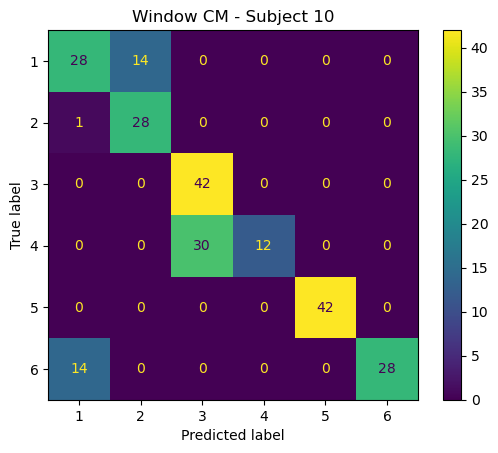


TRIAL ACC: 0.7222222222222222
              precision    recall  f1-score   support

           1       0.50      0.67      0.57         3
           2       0.67      0.67      0.67         3
           3       0.60      1.00      0.75         3
           4       1.00      0.33      0.50         3
           5       1.00      1.00      1.00         3
           6       1.00      0.67      0.80         3

    accuracy                           0.72        18
   macro avg       0.79      0.72      0.71        18
weighted avg       0.79      0.72      0.71        18



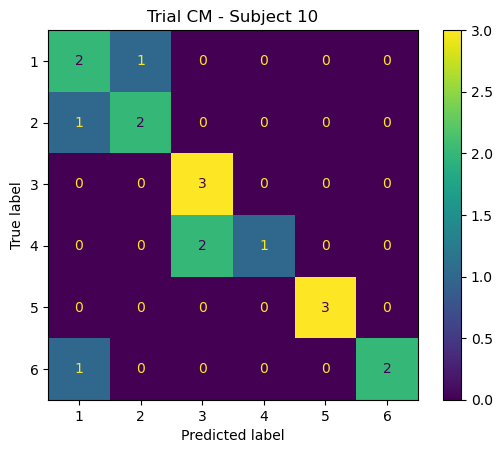


TEST SUBJECT: 11
Model input: (200, 24)
Sensor feature size: 6
Model: "model_10"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_11 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_10 (SensorD  (None, 200, 24)              0         ['input_11[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_60 (Lambda)          (None, 200, 6)               0         ['sensor_dropout_10[0][0]']   
                                                                                                  
 lambda_61 (Lambda)        

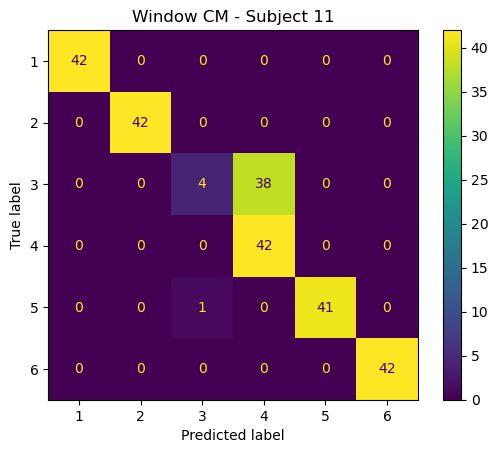


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         3
           4       0.50      1.00      0.67         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.75      0.83      0.78        18
weighted avg       0.75      0.83      0.78        18



c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


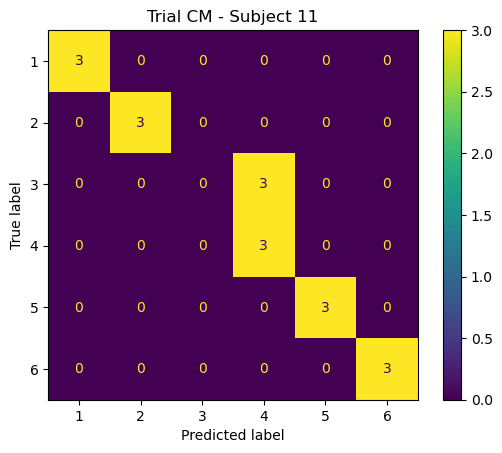


TEST SUBJECT: 12
Model input: (200, 24)
Sensor feature size: 6
Model: "model_11"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_12 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_11 (SensorD  (None, 200, 24)              0         ['input_12[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_66 (Lambda)          (None, 200, 6)               0         ['sensor_dropout_11[0][0]']   
                                                                                                  
 lambda_67 (Lambda)        

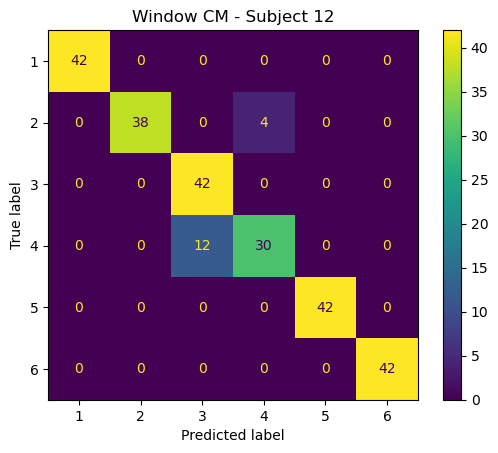


TRIAL ACC: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



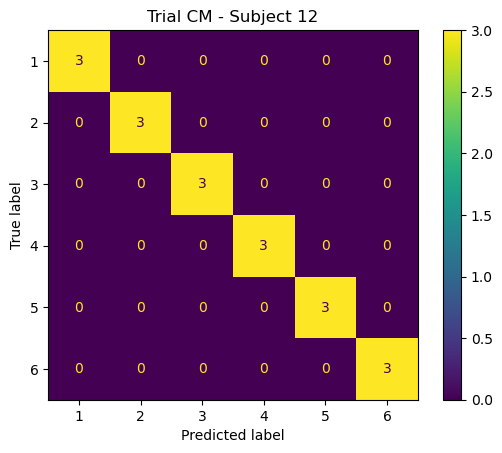


TEST SUBJECT: 13
Model input: (200, 24)
Sensor feature size: 6
Model: "model_12"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_13 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_12 (SensorD  (None, 200, 24)              0         ['input_13[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_72 (Lambda)          (None, 200, 6)               0         ['sensor_dropout_12[0][0]']   
                                                                                                  
 lambda_73 (Lambda)        

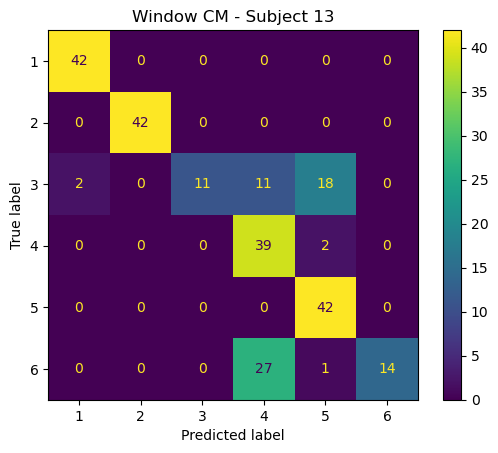


TRIAL ACC: 0.7777777777777778
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.33      0.50         3
           4       0.50      1.00      0.67         3
           5       0.75      1.00      0.86         3
           6       1.00      0.33      0.50         3

    accuracy                           0.78        18
   macro avg       0.88      0.78      0.75        18
weighted avg       0.88      0.78      0.75        18



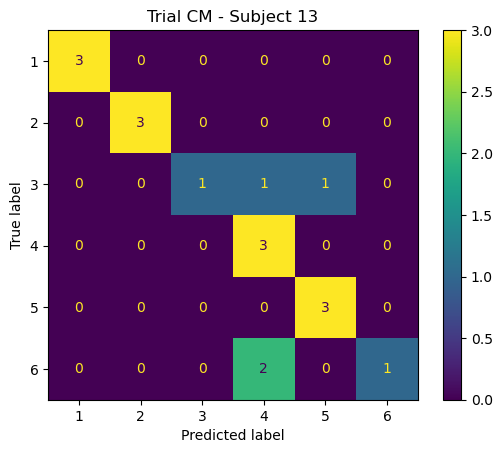


TEST SUBJECT: 14
Model input: (200, 24)
Sensor feature size: 6
Model: "model_13"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_14 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_13 (SensorD  (None, 200, 24)              0         ['input_14[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_78 (Lambda)          (None, 200, 6)               0         ['sensor_dropout_13[0][0]']   
                                                                                                  
 lambda_79 (Lambda)        

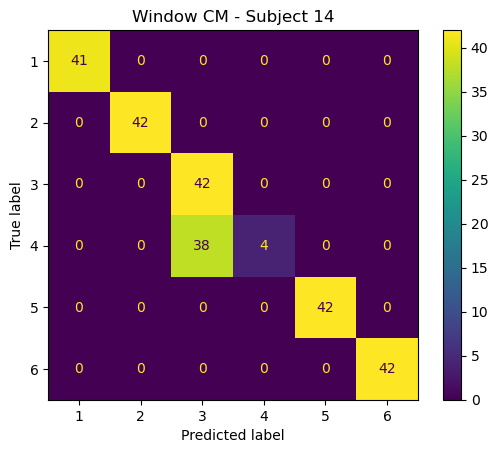


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.50      1.00      0.67         3
           4       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.75      0.83      0.78        18
weighted avg       0.75      0.83      0.78        18



c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


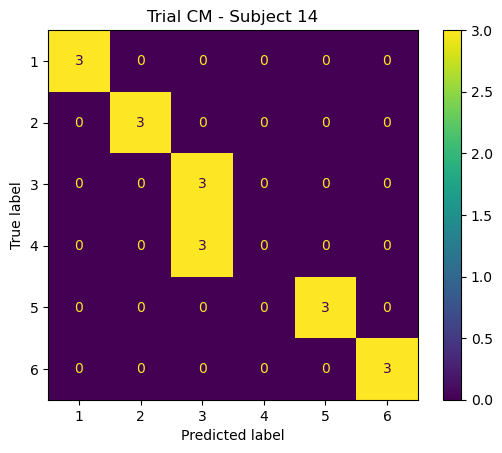


TEST SUBJECT: 15
Model input: (200, 24)
Sensor feature size: 6
Model: "model_14"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_15 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_14 (SensorD  (None, 200, 24)              0         ['input_15[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_84 (Lambda)          (None, 200, 6)               0         ['sensor_dropout_14[0][0]']   
                                                                                                  
 lambda_85 (Lambda)        

c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


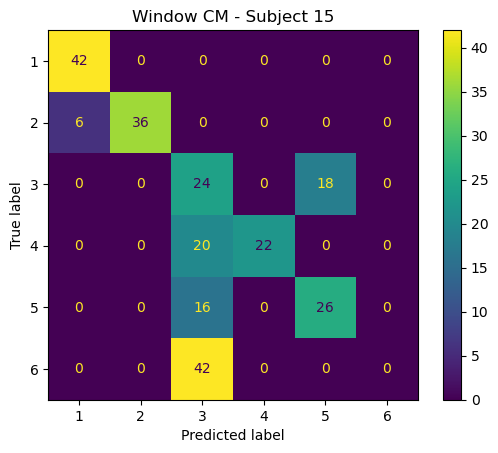


TRIAL ACC: 0.6111111111111112
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.25      0.67      0.36         3
           4       1.00      0.33      0.50         3
           5       0.67      0.67      0.67         3
           6       0.00      0.00      0.00         3

    accuracy                           0.61        18
   macro avg       0.65      0.61      0.59        18
weighted avg       0.65      0.61      0.59        18



c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


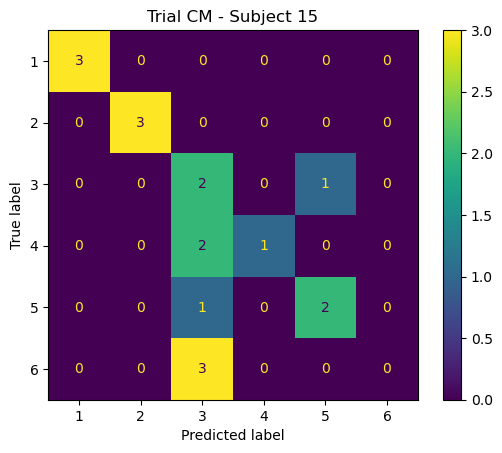


TEST SUBJECT: 17
Model input: (200, 24)
Sensor feature size: 6
Model: "model_15"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_16 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_15 (SensorD  (None, 200, 24)              0         ['input_16[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_90 (Lambda)          (None, 200, 6)               0         ['sensor_dropout_15[0][0]']   
                                                                                                  
 lambda_91 (Lambda)        

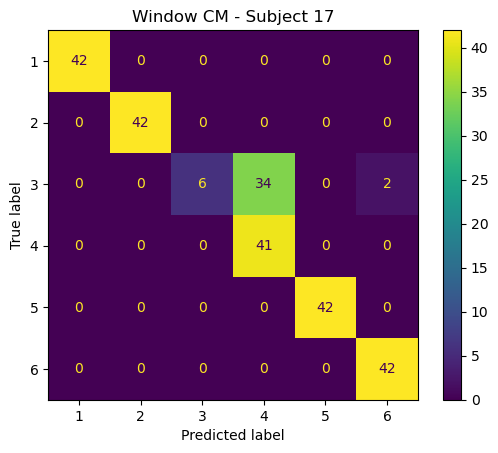


TRIAL ACC: 0.8888888888888888
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.33      0.50         3
           4       0.60      1.00      0.75         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.89        18
   macro avg       0.93      0.89      0.88        18
weighted avg       0.93      0.89      0.88        18



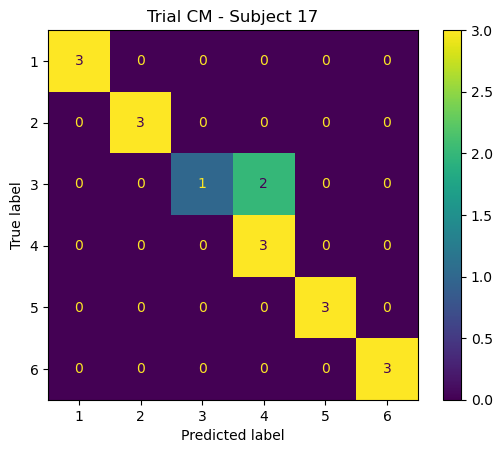


TEST SUBJECT: 18
Model input: (200, 24)
Sensor feature size: 6
Model: "model_16"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_17 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_16 (SensorD  (None, 200, 24)              0         ['input_17[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_96 (Lambda)          (None, 200, 6)               0         ['sensor_dropout_16[0][0]']   
                                                                                                  
 lambda_97 (Lambda)        

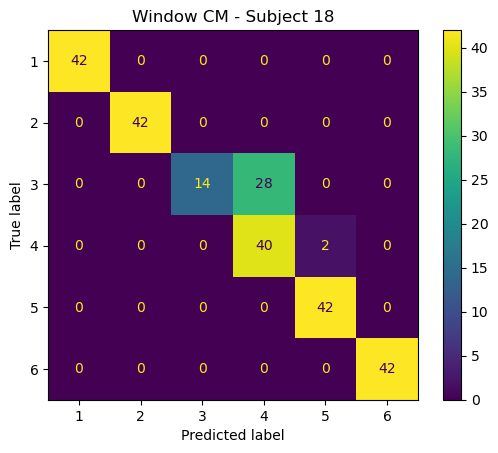


TRIAL ACC: 0.8888888888888888
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.33      0.50         3
           4       0.60      1.00      0.75         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.89        18
   macro avg       0.93      0.89      0.88        18
weighted avg       0.93      0.89      0.88        18



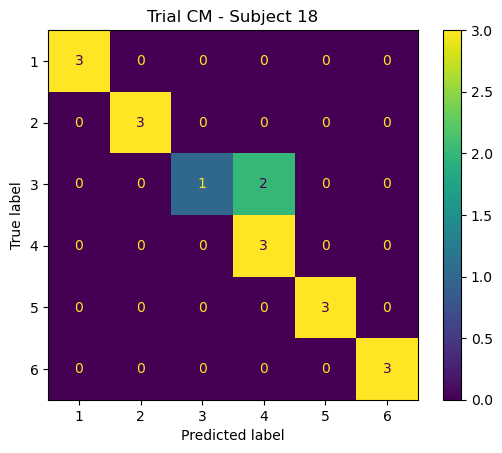


TEST SUBJECT: 19
Model input: (200, 24)
Sensor feature size: 6
Model: "model_17"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_18 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_17 (SensorD  (None, 200, 24)              0         ['input_18[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_102 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_17[0][0]']   
                                                                                                  
 lambda_103 (Lambda)       

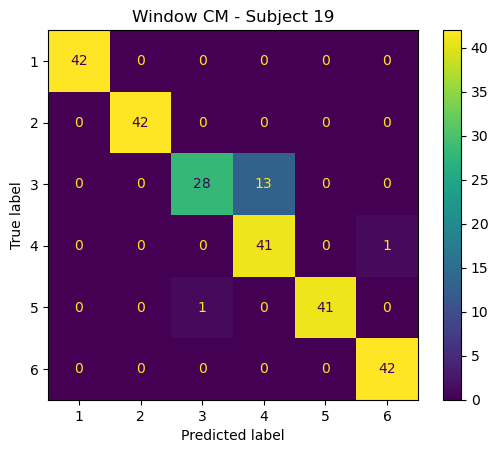


TRIAL ACC: 0.9444444444444444
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       0.75      1.00      0.86         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.94        18
   macro avg       0.96      0.94      0.94        18
weighted avg       0.96      0.94      0.94        18



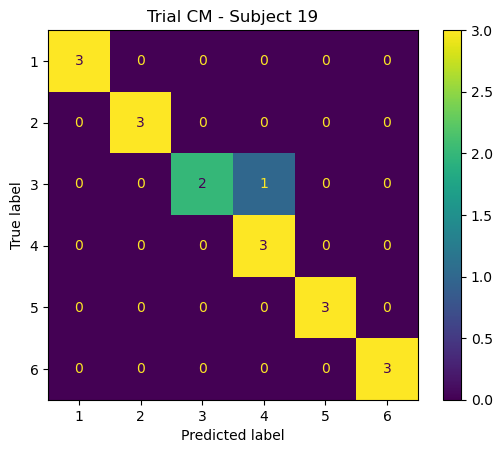


TEST SUBJECT: 20
Model input: (200, 24)
Sensor feature size: 6
Model: "model_18"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_19 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_18 (SensorD  (None, 200, 24)              0         ['input_19[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_108 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_18[0][0]']   
                                                                                                  
 lambda_109 (Lambda)       

c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


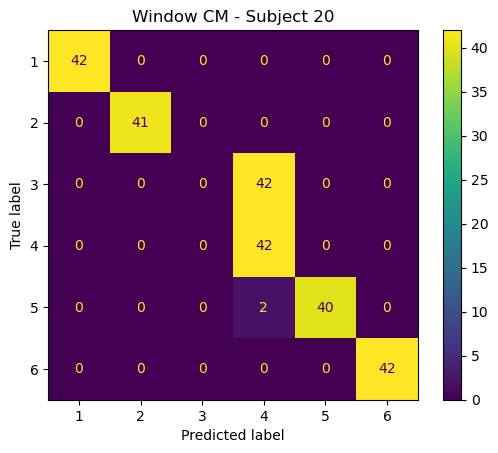


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         3
           4       0.50      1.00      0.67         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.75      0.83      0.78        18
weighted avg       0.75      0.83      0.78        18



c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


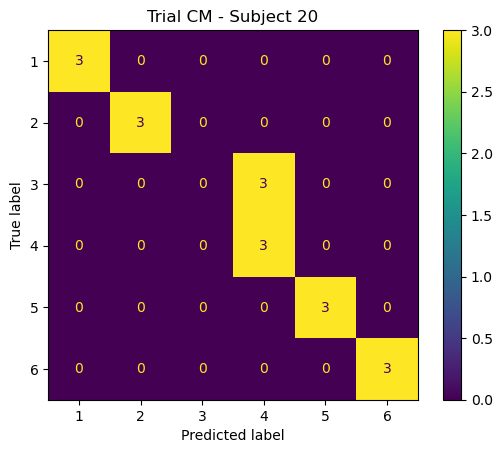


TEST SUBJECT: 22
Model input: (200, 24)
Sensor feature size: 6
Model: "model_19"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_20 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_19 (SensorD  (None, 200, 24)              0         ['input_20[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_114 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_19[0][0]']   
                                                                                                  
 lambda_115 (Lambda)       

c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


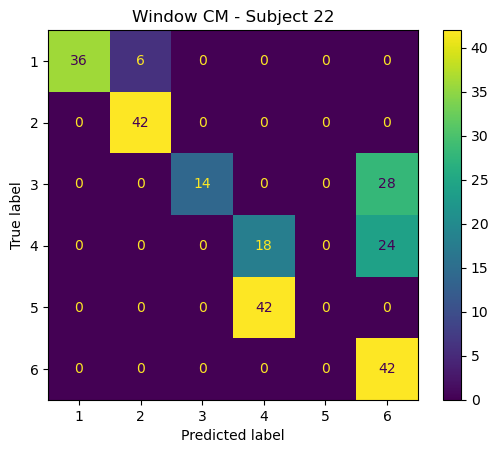


TRIAL ACC: 0.6666666666666666
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.33      0.50         3
           4       0.40      0.67      0.50         3
           5       0.00      0.00      0.00         3
           6       0.50      1.00      0.67         3

    accuracy                           0.67        18
   macro avg       0.65      0.67      0.61        18
weighted avg       0.65      0.67      0.61        18



c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


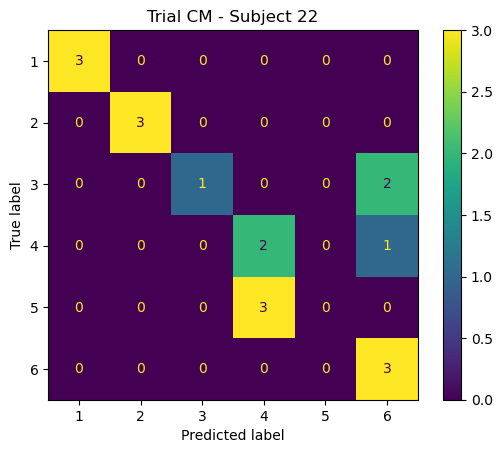


TEST SUBJECT: 23
Model input: (200, 24)
Sensor feature size: 6
Model: "model_20"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_21 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_20 (SensorD  (None, 200, 24)              0         ['input_21[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_120 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_20[0][0]']   
                                                                                                  
 lambda_121 (Lambda)       

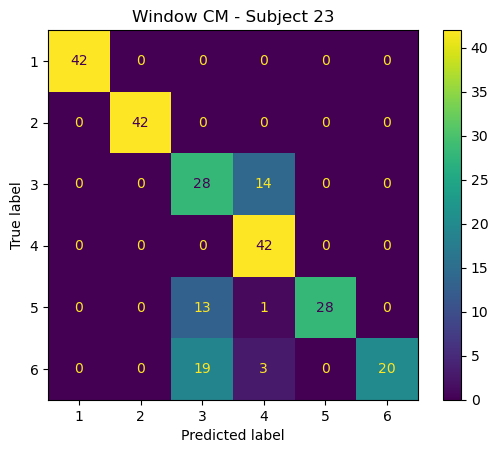


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.50      0.67      0.57         3
           4       0.75      1.00      0.86         3
           5       1.00      0.67      0.80         3
           6       1.00      0.67      0.80         3

    accuracy                           0.83        18
   macro avg       0.88      0.83      0.84        18
weighted avg       0.88      0.83      0.84        18



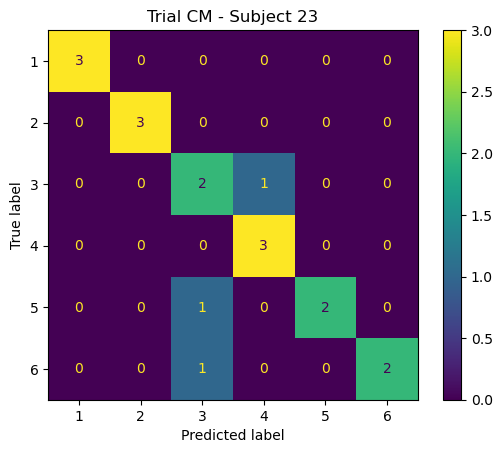


TEST SUBJECT: 24
Model input: (200, 24)
Sensor feature size: 6
Model: "model_21"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_22 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_21 (SensorD  (None, 200, 24)              0         ['input_22[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_126 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_21[0][0]']   
                                                                                                  
 lambda_127 (Lambda)       

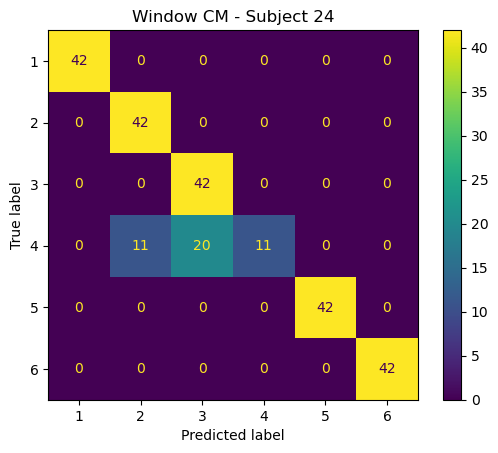


TRIAL ACC: 0.8888888888888888
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       0.75      1.00      0.86         3
           3       0.75      1.00      0.86         3
           4       1.00      0.33      0.50         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.89        18
   macro avg       0.92      0.89      0.87        18
weighted avg       0.92      0.89      0.87        18



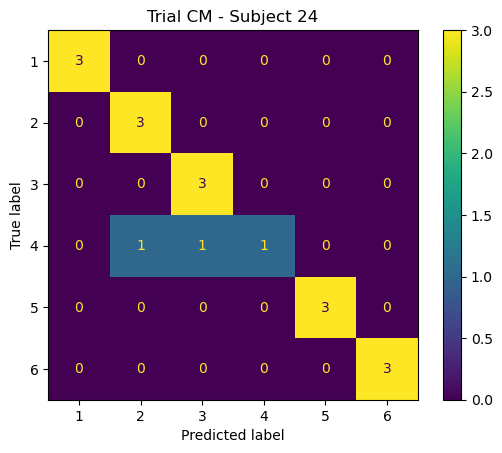


TEST SUBJECT: 25
Model input: (200, 24)
Sensor feature size: 6
Model: "model_22"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_23 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_22 (SensorD  (None, 200, 24)              0         ['input_23[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_132 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_22[0][0]']   
                                                                                                  
 lambda_133 (Lambda)       

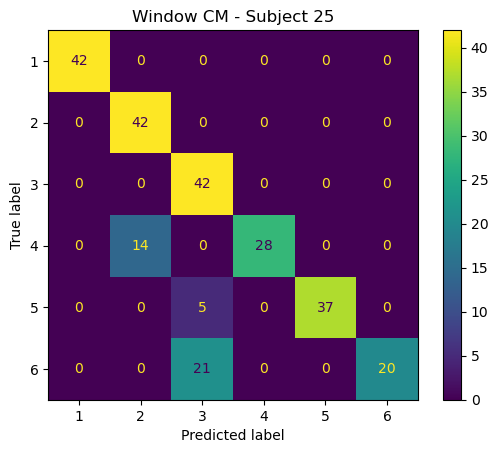


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       0.75      1.00      0.86         3
           3       0.60      1.00      0.75         3
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       1.00      0.33      0.50         3

    accuracy                           0.83        18
   macro avg       0.89      0.83      0.82        18
weighted avg       0.89      0.83      0.82        18



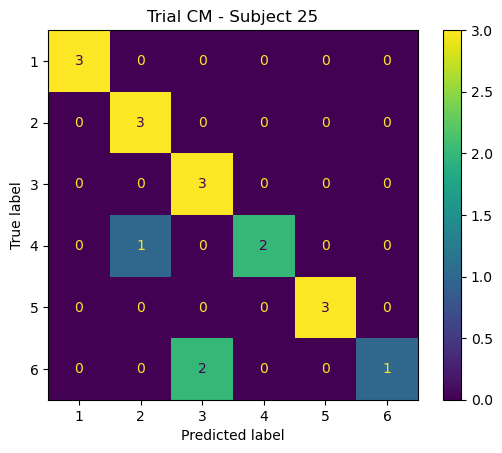


TEST SUBJECT: 27
Model input: (200, 24)
Sensor feature size: 6
Model: "model_23"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_24 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_23 (SensorD  (None, 200, 24)              0         ['input_24[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_138 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_23[0][0]']   
                                                                                                  
 lambda_139 (Lambda)       

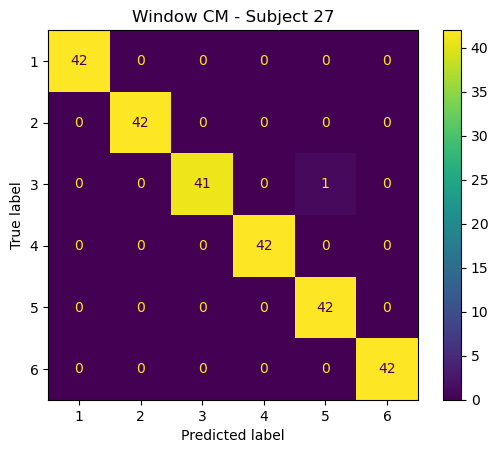


TRIAL ACC: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



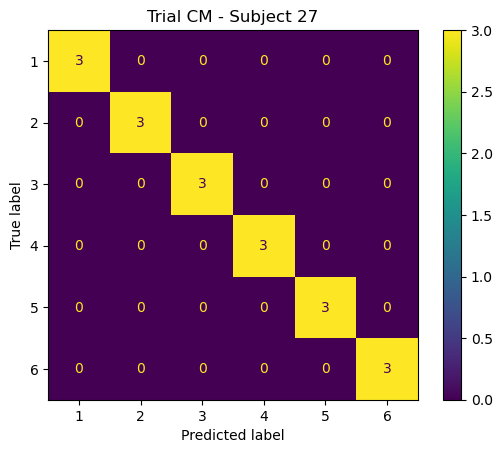


TEST SUBJECT: 28
Model input: (200, 24)
Sensor feature size: 6
Model: "model_24"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_25 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_24 (SensorD  (None, 200, 24)              0         ['input_25[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_144 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_24[0][0]']   
                                                                                                  
 lambda_145 (Lambda)       

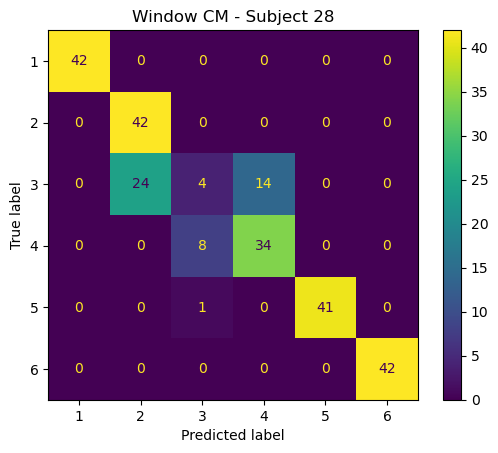


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       0.60      1.00      0.75         3
           3       0.00      0.00      0.00         3
           4       0.75      1.00      0.86         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.72      0.83      0.77        18
weighted avg       0.73      0.83      0.77        18



c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


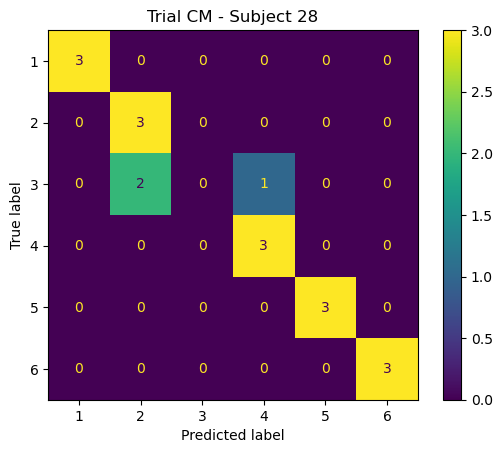


TEST SUBJECT: 30
Model input: (200, 24)
Sensor feature size: 6
Model: "model_25"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_26 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_25 (SensorD  (None, 200, 24)              0         ['input_26[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_150 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_25[0][0]']   
                                                                                                  
 lambda_151 (Lambda)       

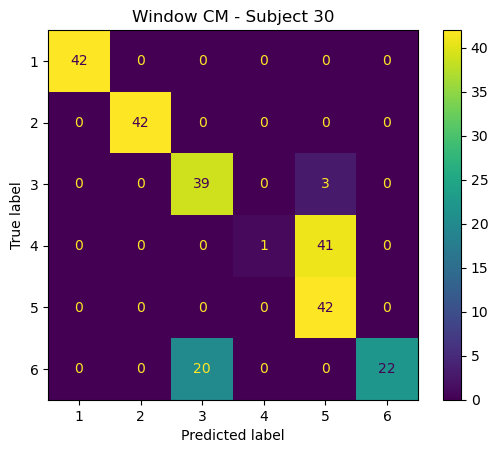


TRIAL ACC: 0.7222222222222222
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.60      1.00      0.75         3
           4       0.00      0.00      0.00         3
           5       0.50      1.00      0.67         3
           6       1.00      0.33      0.50         3

    accuracy                           0.72        18
   macro avg       0.68      0.72      0.65        18
weighted avg       0.68      0.72      0.65        18



c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


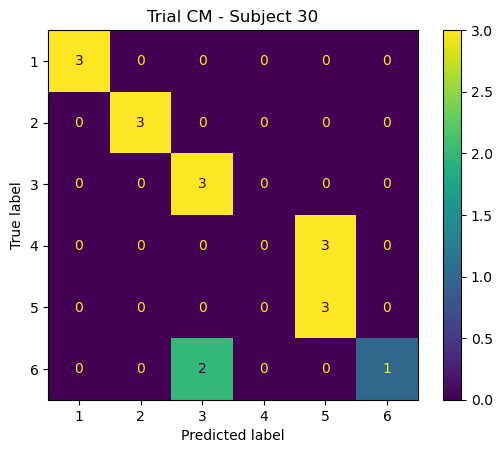


TEST SUBJECT: 31
Model input: (200, 24)
Sensor feature size: 6
Model: "model_26"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_27 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_26 (SensorD  (None, 200, 24)              0         ['input_27[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_156 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_26[0][0]']   
                                                                                                  
 lambda_157 (Lambda)       

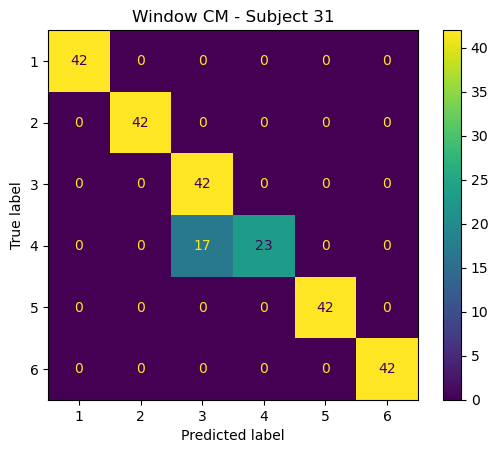


TRIAL ACC: 0.9444444444444444
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.75      1.00      0.86         3
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.94        18
   macro avg       0.96      0.94      0.94        18
weighted avg       0.96      0.94      0.94        18



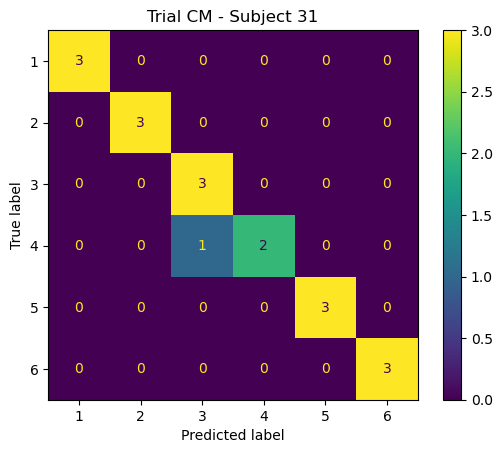


TEST SUBJECT: 32
Model input: (200, 24)
Sensor feature size: 6
Model: "model_27"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_28 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_27 (SensorD  (None, 200, 24)              0         ['input_28[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_162 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_27[0][0]']   
                                                                                                  
 lambda_163 (Lambda)       

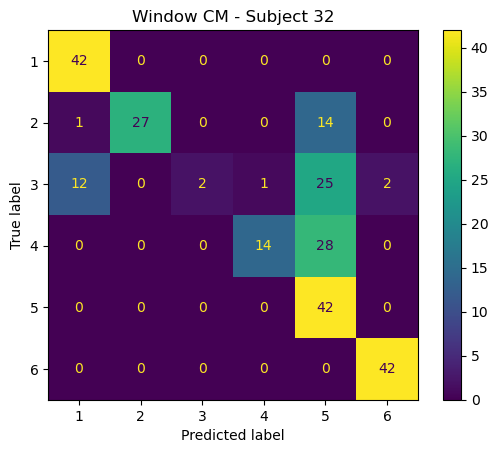


TRIAL ACC: 0.6666666666666666
              precision    recall  f1-score   support

           1       0.75      1.00      0.86         3
           2       1.00      0.67      0.80         3
           3       0.00      0.00      0.00         3
           4       1.00      0.33      0.50         3
           5       0.38      1.00      0.55         3
           6       1.00      1.00      1.00         3

    accuracy                           0.67        18
   macro avg       0.69      0.67      0.62        18
weighted avg       0.69      0.67      0.62        18



c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


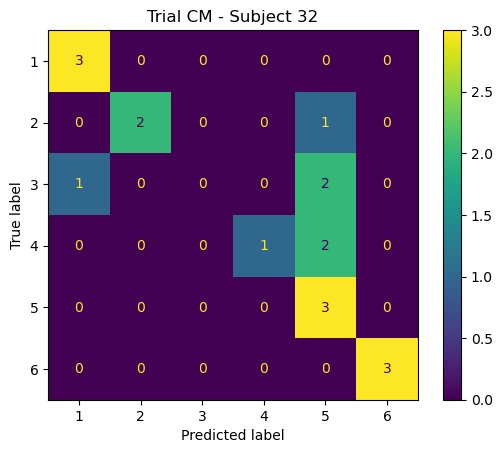


TEST SUBJECT: 33
Model input: (200, 24)
Sensor feature size: 6
Model: "model_28"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_29 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_28 (SensorD  (None, 200, 24)              0         ['input_29[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_168 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_28[0][0]']   
                                                                                                  
 lambda_169 (Lambda)       

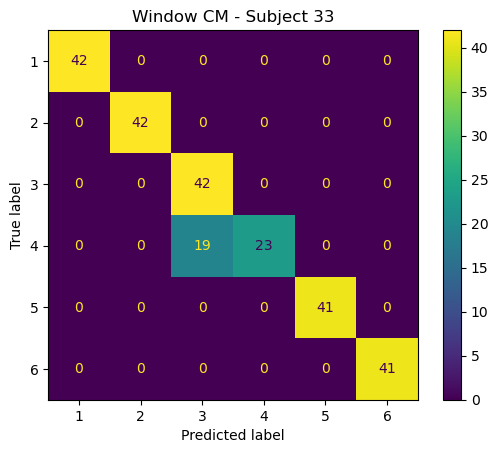


TRIAL ACC: 0.9444444444444444
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.75      1.00      0.86         3
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.94        18
   macro avg       0.96      0.94      0.94        18
weighted avg       0.96      0.94      0.94        18



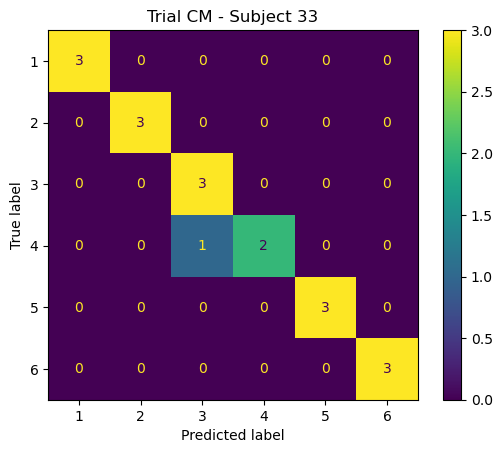


TEST SUBJECT: 34
Model input: (200, 24)
Sensor feature size: 6
Model: "model_29"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_30 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_29 (SensorD  (None, 200, 24)              0         ['input_30[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_174 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_29[0][0]']   
                                                                                                  
 lambda_175 (Lambda)       

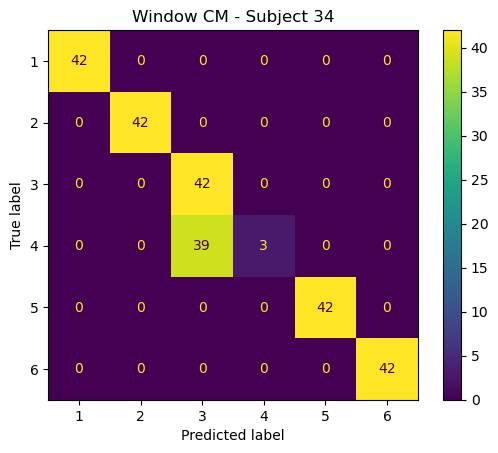


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.50      1.00      0.67         3
           4       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.75      0.83      0.78        18
weighted avg       0.75      0.83      0.78        18



c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


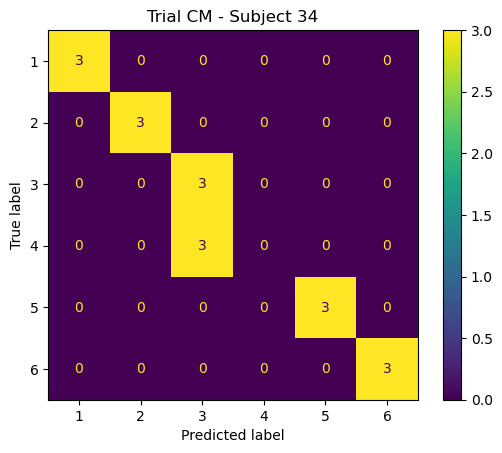


TEST SUBJECT: 35
Model input: (200, 24)
Sensor feature size: 6
Model: "model_30"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_31 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_30 (SensorD  (None, 200, 24)              0         ['input_31[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_180 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_30[0][0]']   
                                                                                                  
 lambda_181 (Lambda)       

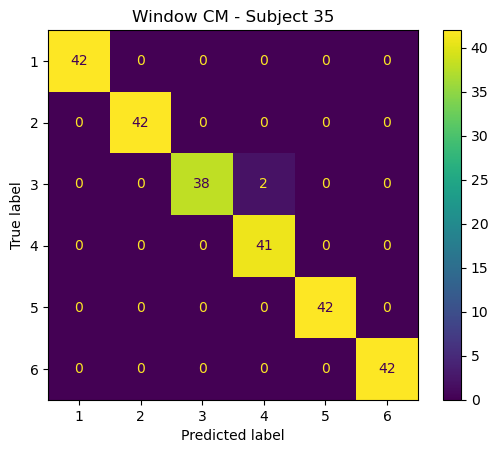


TRIAL ACC: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



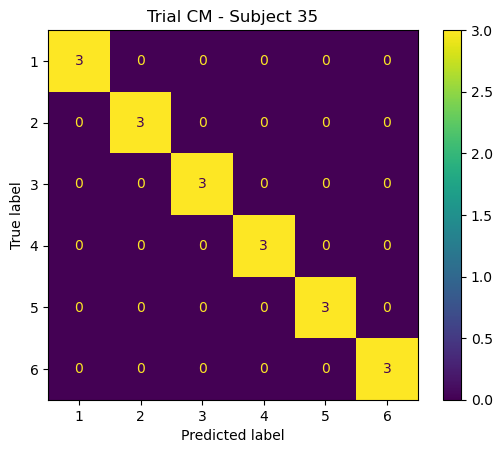


TEST SUBJECT: 36
Model input: (200, 24)
Sensor feature size: 6
Model: "model_31"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_32 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_31 (SensorD  (None, 200, 24)              0         ['input_32[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_186 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_31[0][0]']   
                                                                                                  
 lambda_187 (Lambda)       

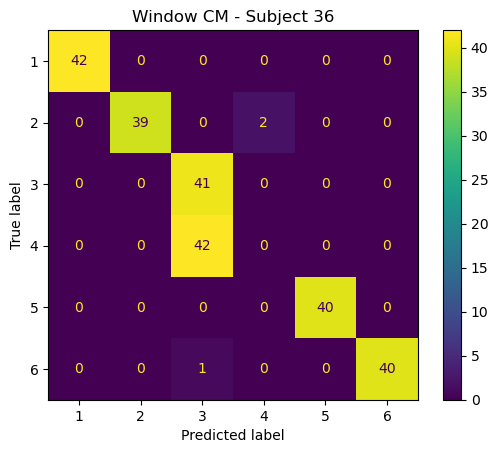


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.50      1.00      0.67         3
           4       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.75      0.83      0.78        18
weighted avg       0.75      0.83      0.78        18



c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


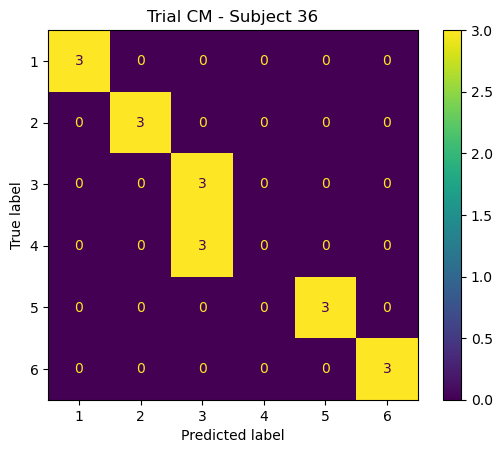


TEST SUBJECT: 37
Model input: (200, 24)
Sensor feature size: 6
Model: "model_32"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_33 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_32 (SensorD  (None, 200, 24)              0         ['input_33[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_192 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_32[0][0]']   
                                                                                                  
 lambda_193 (Lambda)       

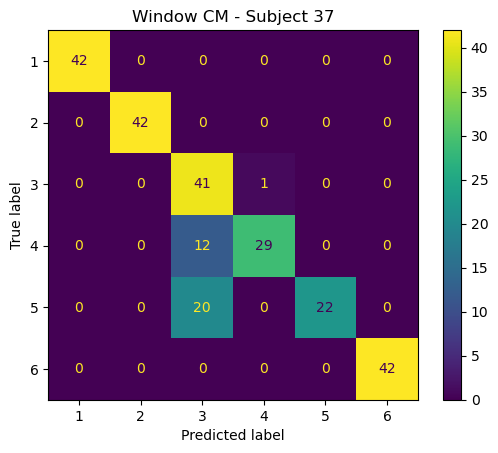


TRIAL ACC: 0.8888888888888888
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.60      1.00      0.75         3
           4       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       1.00      1.00      1.00         3

    accuracy                           0.89        18
   macro avg       0.93      0.89      0.89        18
weighted avg       0.93      0.89      0.89        18



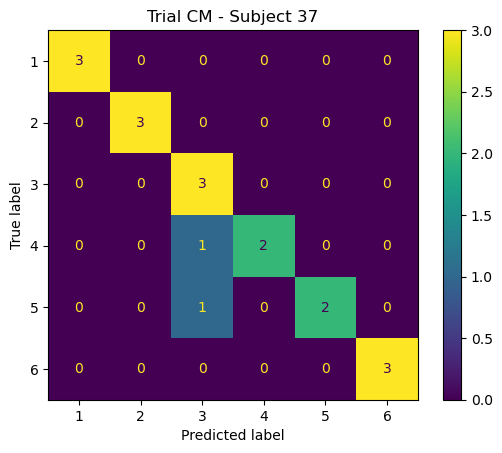


TEST SUBJECT: 38
Model input: (200, 24)
Sensor feature size: 6
Model: "model_33"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_34 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_33 (SensorD  (None, 200, 24)              0         ['input_34[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_198 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_33[0][0]']   
                                                                                                  
 lambda_199 (Lambda)       

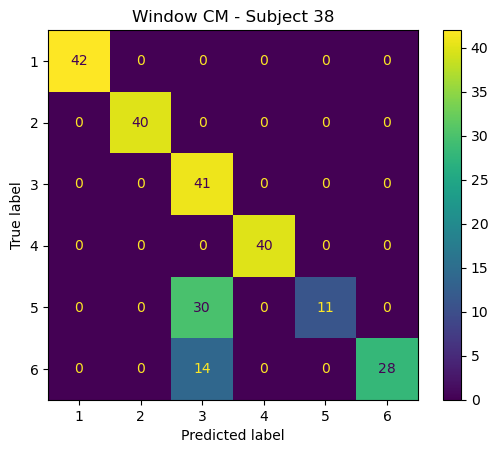


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.50      1.00      0.67         3
           4       1.00      1.00      1.00         3
           5       1.00      0.33      0.50         3
           6       1.00      0.67      0.80         3

    accuracy                           0.83        18
   macro avg       0.92      0.83      0.83        18
weighted avg       0.92      0.83      0.83        18



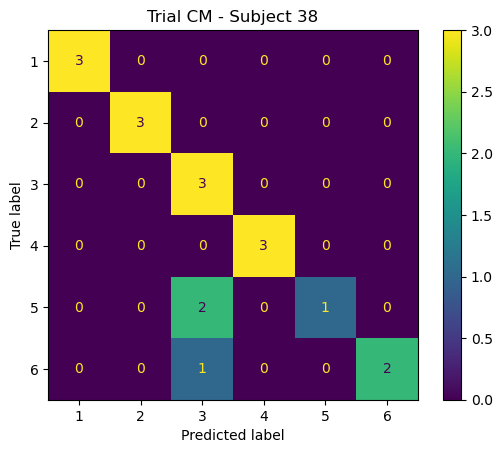


TEST SUBJECT: 39
Model input: (200, 24)
Sensor feature size: 6
Model: "model_34"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_35 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_34 (SensorD  (None, 200, 24)              0         ['input_35[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_204 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_34[0][0]']   
                                                                                                  
 lambda_205 (Lambda)       

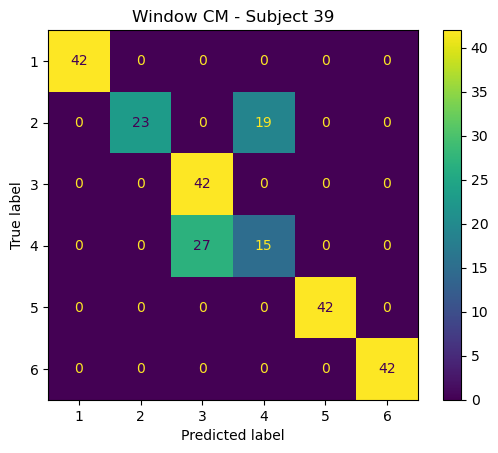


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      0.67      0.80         3
           3       0.60      1.00      0.75         3
           4       0.50      0.33      0.40         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.85      0.83      0.82        18
weighted avg       0.85      0.83      0.83        18



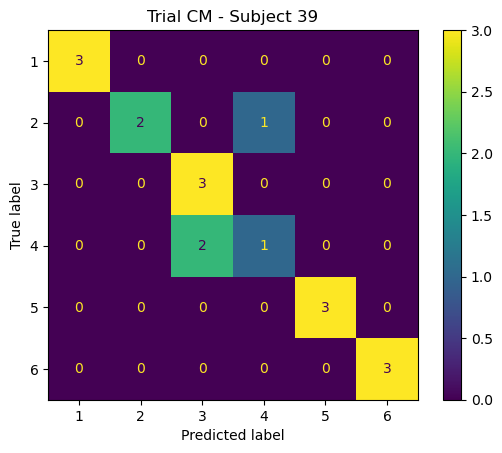


TEST SUBJECT: 40
Model input: (200, 24)
Sensor feature size: 6
Model: "model_35"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_36 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_35 (SensorD  (None, 200, 24)              0         ['input_36[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_210 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_35[0][0]']   
                                                                                                  
 lambda_211 (Lambda)       

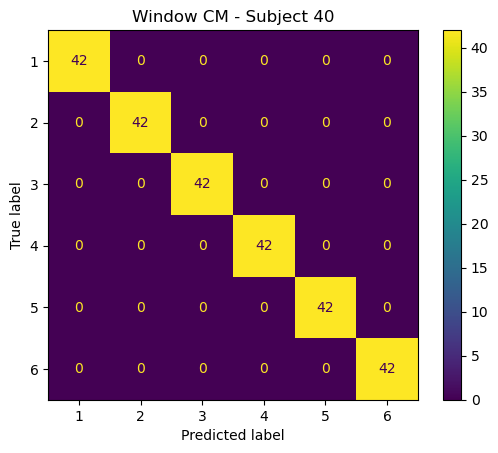


TRIAL ACC: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



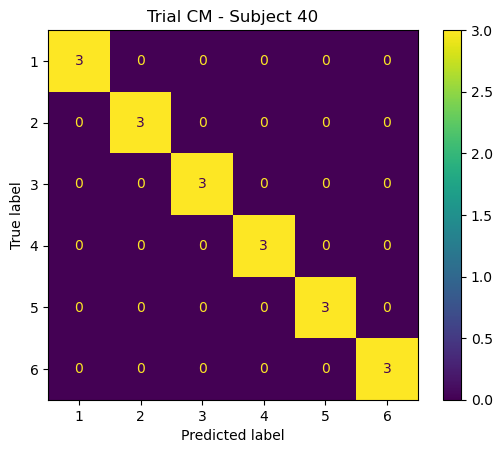


TEST SUBJECT: 41
Model input: (200, 24)
Sensor feature size: 6
Model: "model_36"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_37 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_36 (SensorD  (None, 200, 24)              0         ['input_37[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_216 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_36[0][0]']   
                                                                                                  
 lambda_217 (Lambda)       

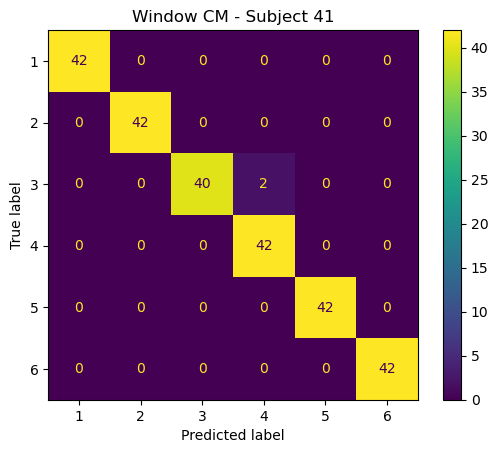


TRIAL ACC: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



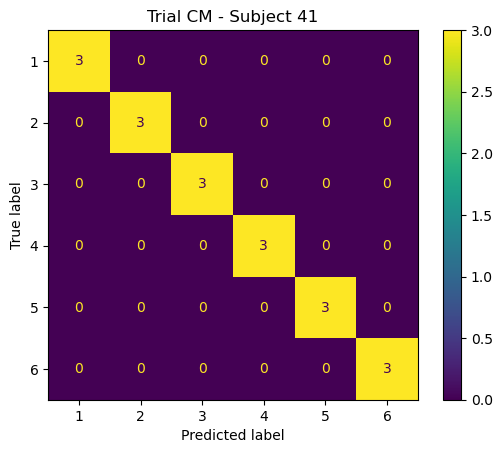


TEST SUBJECT: 42
Model input: (200, 24)
Sensor feature size: 6
Model: "model_37"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_38 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_37 (SensorD  (None, 200, 24)              0         ['input_38[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_222 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_37[0][0]']   
                                                                                                  
 lambda_223 (Lambda)       

c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


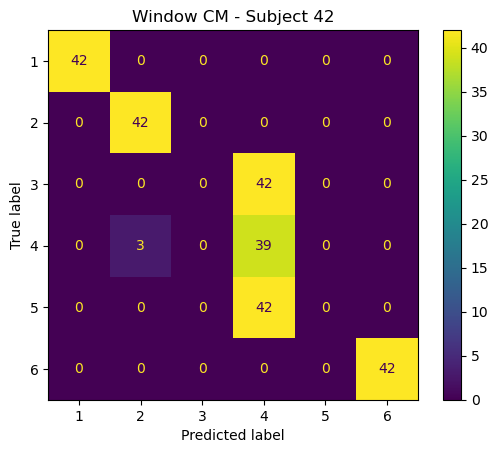


TRIAL ACC: 0.6666666666666666
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         3
           4       0.33      1.00      0.50         3
           5       0.00      0.00      0.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.67        18
   macro avg       0.56      0.67      0.58        18
weighted avg       0.56      0.67      0.58        18



c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


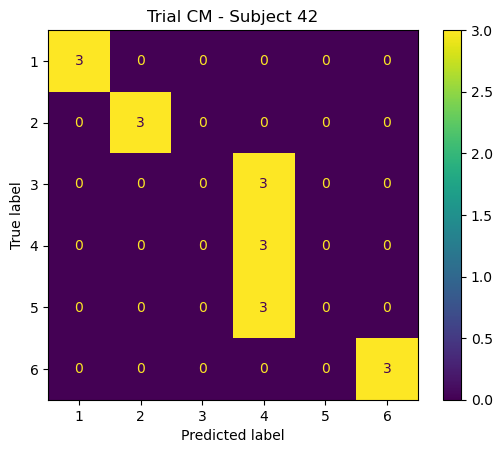


TEST SUBJECT: 43
Model input: (200, 24)
Sensor feature size: 6
Model: "model_38"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_39 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_38 (SensorD  (None, 200, 24)              0         ['input_39[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_228 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_38[0][0]']   
                                                                                                  
 lambda_229 (Lambda)       

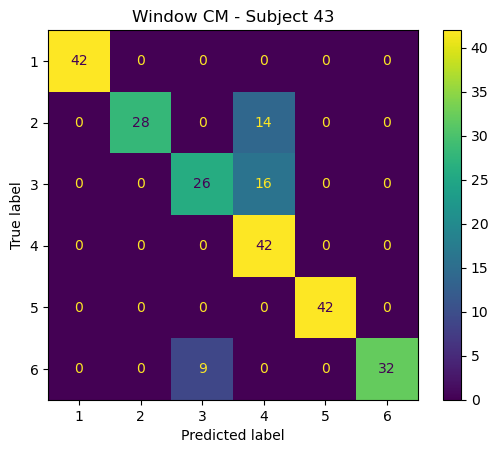


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      0.67      0.80         3
           3       0.67      0.67      0.67         3
           4       0.60      1.00      0.75         3
           5       1.00      1.00      1.00         3
           6       1.00      0.67      0.80         3

    accuracy                           0.83        18
   macro avg       0.88      0.83      0.84        18
weighted avg       0.88      0.83      0.84        18



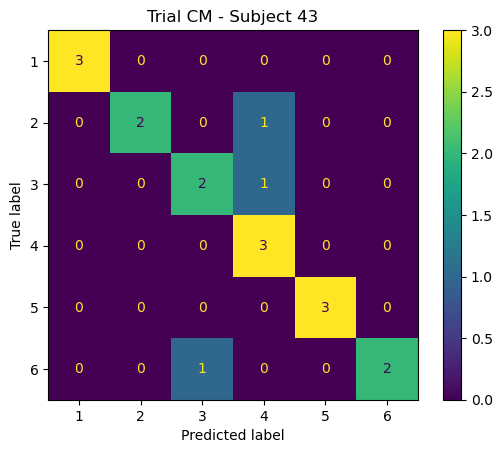


TEST SUBJECT: 44
Model input: (200, 24)
Sensor feature size: 6
Model: "model_39"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_40 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_39 (SensorD  (None, 200, 24)              0         ['input_40[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_234 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_39[0][0]']   
                                                                                                  
 lambda_235 (Lambda)       

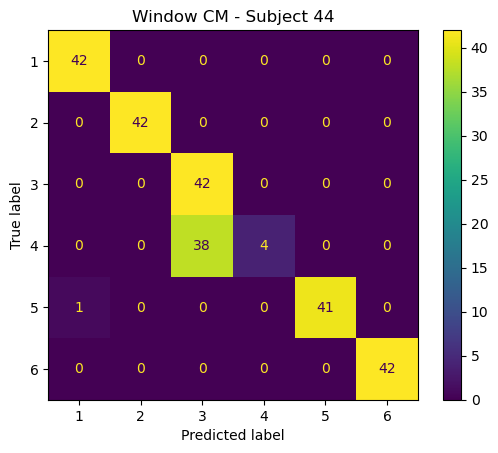


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.50      1.00      0.67         3
           4       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.75      0.83      0.78        18
weighted avg       0.75      0.83      0.78        18



c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Ayat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


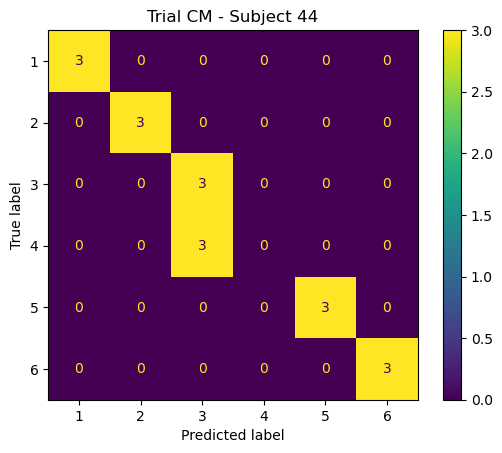


TEST SUBJECT: 45
Model input: (200, 24)
Sensor feature size: 6
Model: "model_40"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_41 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_40 (SensorD  (None, 200, 24)              0         ['input_41[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_240 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_40[0][0]']   
                                                                                                  
 lambda_241 (Lambda)       

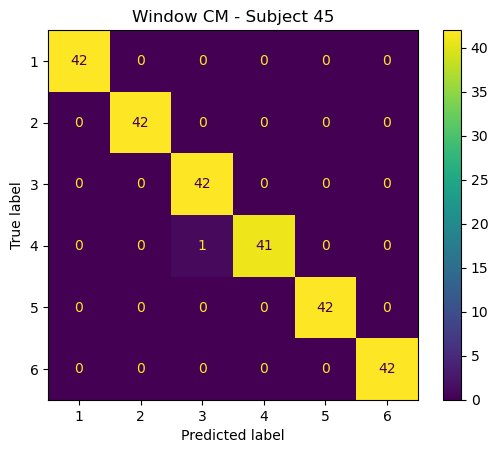


TRIAL ACC: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



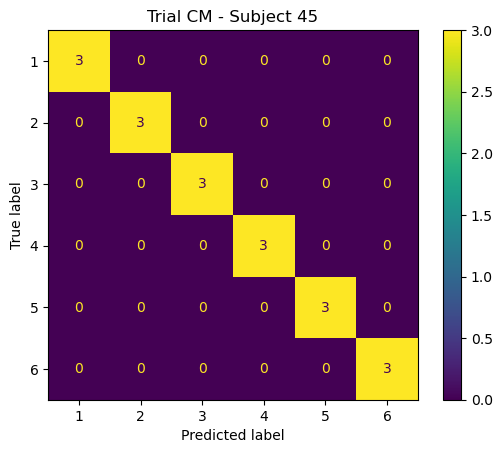


TEST SUBJECT: 46
Model input: (200, 24)
Sensor feature size: 6
Model: "model_41"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_42 (InputLayer)       [(None, 200, 24)]            0         []                            
                                                                                                  
 sensor_dropout_41 (SensorD  (None, 200, 24)              0         ['input_42[0][0]']            
 ropout)                                                                                          
                                                                                                  
 lambda_246 (Lambda)         (None, 200, 6)               0         ['sensor_dropout_41[0][0]']   
                                                                                                  
 lambda_247 (Lambda)       

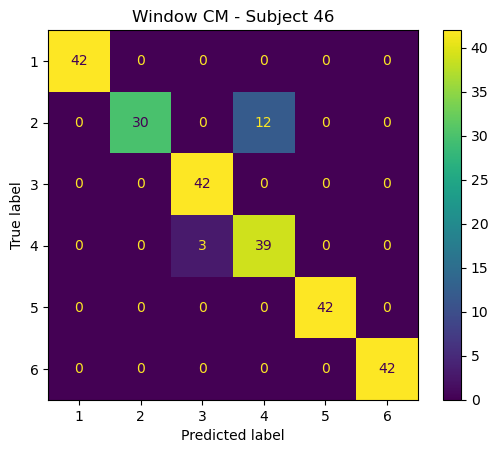


TRIAL ACC: 0.9444444444444444
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      0.67      0.80         3
           3       1.00      1.00      1.00         3
           4       0.75      1.00      0.86         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.94        18
   macro avg       0.96      0.94      0.94        18
weighted avg       0.96      0.94      0.94        18



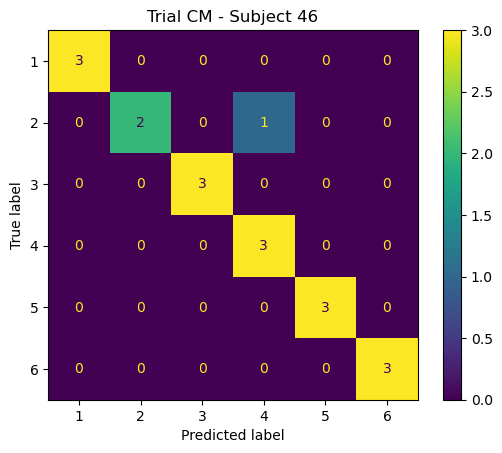

In [ ]:
# CELL 9
# =========================================
# LOSO LOOP (PER-FOLD ONLY)
# =========================================

from collections import defaultdict
import gc

EXCLUDED_SUBJECTS = [16, 21, 26, 29]

subjects = sorted(
    s for s in np.unique(subj_all)
    if s not in EXCLUDED_SUBJECTS
)

window_scores = []
trial_scores = []

all_window_true = []
all_window_pred = []

all_trial_true = []
all_trial_pred = []
all_trial_subjects = []

# ✅ store probs + attention inputs
all_window_probs = []
all_attention_inputs = []   # 🔥 NEW

fold_results = []

for test_subject in subjects:

    print("\n============================")
    print("TEST SUBJECT:", test_subject)
    print("============================")

    # -----------------------
    # SPLIT
    # -----------------------
    train_subjects = [s for s in subjects if s != test_subject]

    val_size = max(1, int(0.2 * len(train_subjects)))
    val_subjects = np.random.choice(train_subjects, size=val_size, replace=False)

    train_subjects_final = [s for s in train_subjects if s not in val_subjects]

    train_mask = np.isin(subj_all, train_subjects_final)
    val_mask   = np.isin(subj_all, val_subjects)
    test_mask  = subj_all == test_subject

    X_train = X_all[train_mask]
    y_train = y_all[train_mask]

    X_val   = X_all[val_mask]
    y_val   = y_all[val_mask]

    X_test  = X_all[test_mask]
    y_test  = y_all[test_mask]

    trial_test = trial_all[test_mask]
    subject_test = subj_all[test_mask]

    # -----------------------
    # NORMALIZATION
    # -----------------------
    means, stds = compute_sensor_norm(X_train)

    X_train = apply_sensor_norm(X_train, means, stds)
    X_val   = apply_sensor_norm(X_val, means, stds)
    X_test  = apply_sensor_norm(X_test, means, stds)

    # 🔥 store normalized test for attention
    all_attention_inputs.append(X_test)

    # -----------------------
    # ONE HOT
    # -----------------------
    y_train_cat = keras.utils.to_categorical(y_train, len(POSTURES))
    y_val_cat   = keras.utils.to_categorical(y_val, len(POSTURES))

    # -----------------------
    # MODEL
    # -----------------------
    model = build_model(X_train.shape[1:])

    early = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    hist = model.fit(
        X_train,
        y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=60,
        batch_size=32,
        callbacks=[early, lr_scheduler],
        verbose=1
    )

    # -----------------------
    # WINDOW LEVEL
    # -----------------------
    probs = model.predict(X_test, verbose=0)

    y_pred = np.argmax(probs, axis=1)
    y_true = y_test

    all_window_probs.append(probs)

    window_acc = np.mean(y_pred == y_true)
    window_scores.append(window_acc)

    print("\nWINDOW ACC:", window_acc)
    print(classification_report(y_true, y_pred, target_names=POSTURES))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=POSTURES).plot()
    plt.title(f"Window CM - Subject {test_subject}")
    plt.show()

    all_window_true.extend(y_true)
    all_window_pred.extend(y_pred)

    # -----------------------
    # TRIAL LEVEL
    # -----------------------
    trial_probs = defaultdict(list)
    trial_true = {}

    for p,true,s,t in zip(probs, y_true, subject_test, trial_test):
        key = (s,t)
        trial_probs[key].append(p)
        trial_true[key] = true

    trial_pred = []
    trial_true_list = []
    trial_subjects = []

    for k in trial_probs:
        w = np.array(trial_probs[k])
        summed = np.sum(np.log(w + 1e-8), axis=0)
        pred = np.argmax(summed)

        trial_pred.append(pred)
        trial_true_list.append(trial_true[k])
        trial_subjects.append(k[0])

    trial_pred = np.array(trial_pred)
    trial_true_list = np.array(trial_true_list)
    trial_subjects = np.array(trial_subjects)

    trial_acc = np.mean(trial_pred == trial_true_list)
    trial_scores.append(trial_acc)

    print("\nTRIAL ACC:", trial_acc)
    print(classification_report(trial_true_list, trial_pred, target_names=POSTURES))

    cm = confusion_matrix(trial_true_list, trial_pred)
    ConfusionMatrixDisplay(cm, display_labels=POSTURES).plot()
    plt.title(f"Trial CM - Subject {test_subject}")
    plt.show()

    all_trial_true.extend(trial_true_list)
    all_trial_pred.extend(trial_pred)
    all_trial_subjects.extend(trial_subjects)

    # SAVE FINAL MODEL
    if test_subject == subjects[-1]:
        final_model = model
        final_means = means
        final_stds = stds

    del model, hist
    gc.collect()


===== FINAL LOSO RESULTS =====
Avg Window Acc: 0.8549807360763382
Avg Trial Acc: 0.865079365079365
Probs shape: (10544, 6)
True shape: (10544,)

WINDOW METRICS
              precision    recall  f1-score   support

           1       0.97      0.99      0.98      1762
           2       0.96      0.94      0.95      1747
           3       0.68      0.73      0.70      1759
           4       0.71      0.70      0.70      1756
           5       0.88      0.89      0.89      1760
           6       0.95      0.88      0.92      1760

    accuracy                           0.86     10544
   macro avg       0.86      0.86      0.86     10544
weighted avg       0.86      0.86      0.86     10544



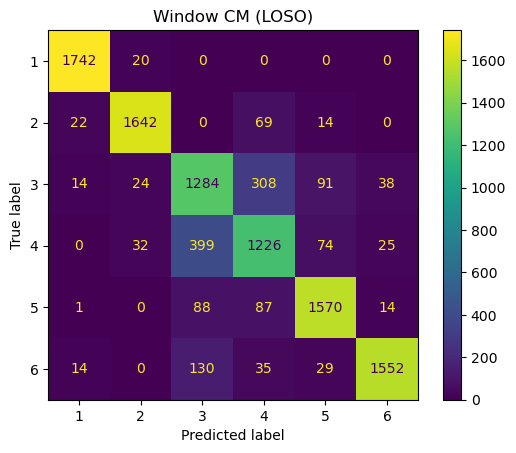


TRIAL METRICS
              precision    recall  f1-score   support

           1       0.97      0.99      0.98       126
           2       0.96      0.94      0.95       126
           3       0.69      0.75      0.72       126
           4       0.73      0.72      0.73       126
           5       0.90      0.90      0.90       126
           6       0.97      0.88      0.92       126

    accuracy                           0.87       756
   macro avg       0.87      0.87      0.87       756
weighted avg       0.87      0.87      0.87       756



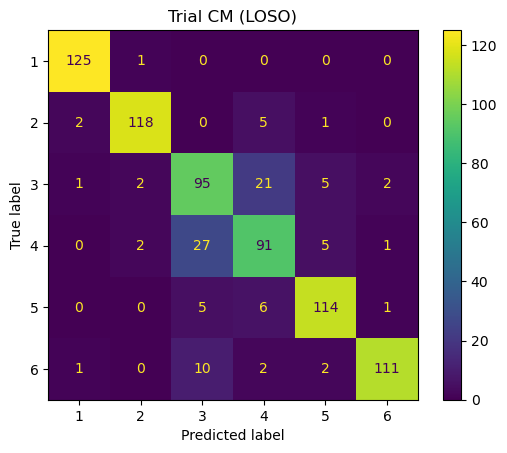


===== SUBJECT RESULTS =====
Avg Subject Acc: 0.8849206349206349

SUBJECT METRICS
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        42
           2       0.95      0.98      0.96        42
           3       0.72      0.79      0.75        42
           4       0.75      0.71      0.73        42
           5       0.93      0.93      0.93        42
           6       0.97      0.90      0.94        42

    accuracy                           0.88       252
   macro avg       0.89      0.88      0.89       252
weighted avg       0.89      0.88      0.89       252



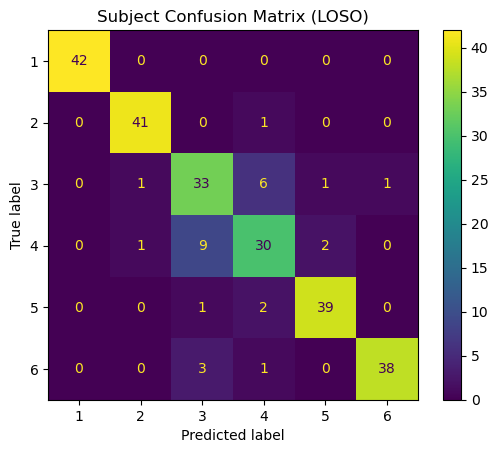


===== LATENCY =====
Mean: 100.747 ms
Std: 22.972 ms


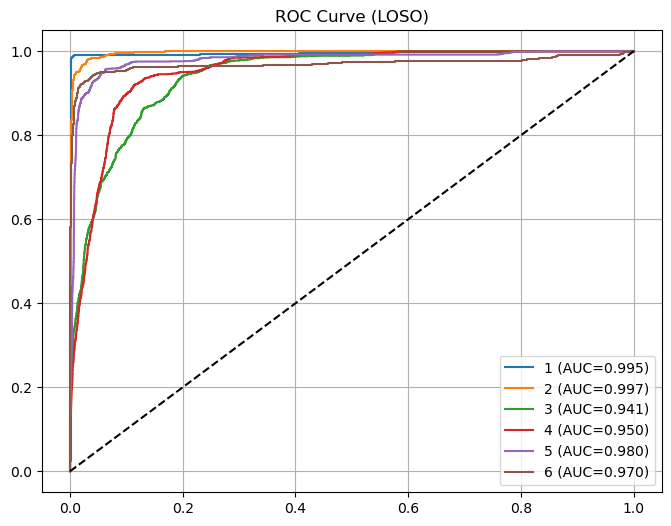


===== ROC AUC SCORES =====
1: 0.9946
2: 0.9966
3: 0.9407
4: 0.9505
5: 0.9800
6: 0.9696


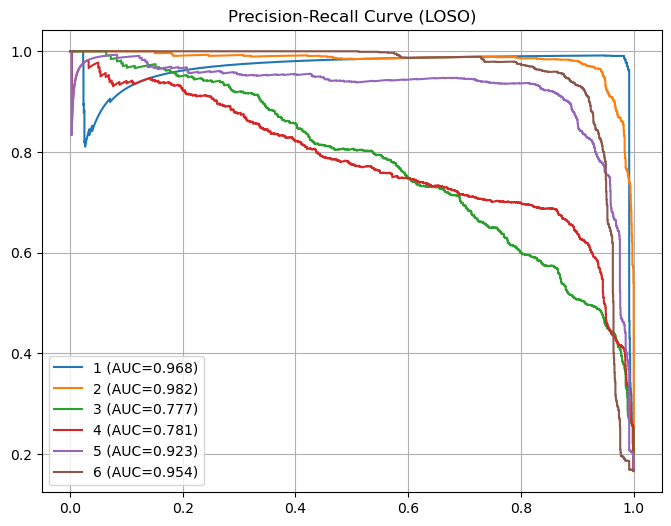

In [10]:
#  cell 10
# =========================================
# FINAL RESULTS (ALL FOLDS)
# =========================================

from collections import defaultdict
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import time

print("\n===== FINAL LOSO RESULTS =====")

print("Avg Window Acc:", np.mean(window_scores))
print("Avg Trial Acc:", np.mean(trial_scores))


# =========================================
# FIX PROB SHAPE
# =========================================
all_window_probs = np.concatenate(all_window_probs, axis=0)

print("Probs shape:", all_window_probs.shape)
print("True shape:", np.array(all_window_true).shape)


# -----------------------
# WINDOW METRICS
# -----------------------
print("\nWINDOW METRICS")
print(classification_report(all_window_true, all_window_pred, target_names=POSTURES))

cm = confusion_matrix(all_window_true, all_window_pred)
ConfusionMatrixDisplay(cm, display_labels=POSTURES).plot()
plt.title("Window CM (LOSO)")
plt.show()


# -----------------------
# TRIAL METRICS
# -----------------------
print("\nTRIAL METRICS")
print(classification_report(all_trial_true, all_trial_pred, target_names=POSTURES))

cm = confusion_matrix(all_trial_true, all_trial_pred)
ConfusionMatrixDisplay(cm, display_labels=POSTURES).plot()
plt.title("Trial CM (LOSO)")
plt.show()


# =========================================
# SUBJECT LEVEL (VOTING)
# =========================================

subject_votes = defaultdict(list)
subject_true = {}

for pred, true, s in zip(all_trial_pred, all_trial_true, all_trial_subjects):
    key = (s, true)
    subject_votes[key].append(pred)
    subject_true[key] = true

all_subject_pred = []
all_subject_true = []

for k in subject_votes:
    votes = np.array(subject_votes[k])
    pred = np.bincount(votes).argmax()

    all_subject_pred.append(pred)
    all_subject_true.append(subject_true[k])

all_subject_pred = np.array(all_subject_pred)
all_subject_true = np.array(all_subject_true)

print("\n===== SUBJECT RESULTS =====")
print("Avg Subject Acc:", np.mean(all_subject_pred == all_subject_true))

# -----------------------
# SUBJECT METRICS
# -----------------------
print("\nSUBJECT METRICS")
print(classification_report(
    all_subject_true,
    all_subject_pred,
    labels=np.arange(len(POSTURES)),
    target_names=POSTURES,
    zero_division=0
))

# -----------------------
# SUBJECT CONFUSION MATRIX
# -----------------------
cm = confusion_matrix(
    all_subject_true,
    all_subject_pred,
    labels=np.arange(len(POSTURES))
)

ConfusionMatrixDisplay(cm, display_labels=POSTURES).plot()
plt.title("Subject Confusion Matrix (LOSO)")
plt.show()


# =========================================
# REAL DEPLOYMENT LATENCY
# =========================================

sample = X_all[0:1]
sample = apply_sensor_norm(sample, final_means, final_stds)

for _ in range(10):
    final_model.predict(sample, verbose=0)

latencies = []
N = 100

for _ in range(N):
    start = time.perf_counter()
    final_model.predict(sample, verbose=0)
    end = time.perf_counter()
    latencies.append(end - start)

latencies = np.array(latencies)

print("\n===== LATENCY =====")
print(f"Mean: {latencies.mean()*1000:.3f} ms")
print(f"Std: {latencies.std()*1000:.3f} ms")


# =========================================
# ROC CURVE
# =========================================

y_true_bin = label_binarize(all_window_true, classes=np.arange(len(POSTURES)))

plt.figure(figsize=(8,6))

for i in range(len(POSTURES)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_window_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{POSTURES[i]} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve (LOSO)")
plt.legend()
plt.grid()
plt.show()

print("\n===== ROC AUC SCORES =====")
for i in range(len(POSTURES)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_window_probs[:, i])
    print(f"{POSTURES[i]}: {auc(fpr, tpr):.4f}")


# =========================================
# PR CURVE
# =========================================

plt.figure(figsize=(8,6))

for i in range(len(POSTURES)):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        all_window_probs[:, i]
    )

    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, label=f"{POSTURES[i]} (AUC={pr_auc:.3f})")

plt.title("Precision-Recall Curve (LOSO)")
plt.legend()
plt.grid()
plt.show()